In [1]:
import numpy as np
import pandas as pd
from calc_rates2 import calc_rates
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.metrics import AUC

print('TensorFlow:', tf.__version__)

I0000 00:00:1785676242.881140   37424 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785676242.881834   37424 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785676243.052244   37424 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785676244.899690   37424 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

TensorFlow: 2.21.0


In [ ]:
# Leer todos los archivos
dfs = []
lens = []
#Los primeros años tienen algunas carencias de datos y 2021 es un año con muchos.
for year in range(2014,2027):
    df = pd.read_csv(f"../Data/Procesed data/Re-formulated data/{year}_LoL_esports_match_data_from_OraclesElixir.csv",low_memory=False)
    lens.append(len(df))
    dfs.append(df)
# [2014, 2015, 2016,  2017,  2018,  2019,  2020,  2021,  2022,  2023,  2024,  2025,  2026]
# [1836, 3630, 8428, 11010, 13472, 16250, 19494, 24604, 25058, 22212, 20390, 20082, 12508]
# | -      -    -  [train                     ][val         ] [test       ][train        ]
# print(lens)

complete_set  = pd.concat(dfs, ignore_index=True)
complete_set = calc_rates(complete_set)

index_train = sum(lens[i] for i in range(3))
index_val = sum(lens[i] for i in range(7))
index_test = sum(lens[i] for i in range(9))
index_final = sum(lens[i] for i in range(11))

print("Train: ",index_val-index_train + len(complete_set)-index_final)
print("Val: ",index_test-index_val)
print("Test: ",index_final-index_test)

train_set = complete_set[index_train:index_val] + complete_set[index_final:]
val_set = complete_set[index_val:index_test]
test_set = complete_set[index_test:index_final]

train_set.to_csv("../Data/Net/train_data2.csv",index=False)
val_set.to_csv("../Data/Net/val_data2.csv",index=False)
test_set.to_csv("../Data/Net/test_data2.csv",index=False)



# Poda de columnas y datos

In [3]:
def remove_labels(df, label_name):
    X = df.drop(label_name, axis=1)
    y = df[label_name].copy()
    return (X, y)

In [4]:
X_train, y_train = remove_labels(train_set, 'result')
X_val, y_val = remove_labels(val_set, 'result')
X_test, y_test = remove_labels(test_set, 'result')

In [5]:
assert(len(X_train) == len(y_train))
print("Entrenamiento:",len(X_train))

assert(len(X_val) == len(y_val))
print("Val:",len(X_val))

assert(len(X_test) == len(y_test))
print("Prueba:",len(X_test))

Entrenamiento: 60226
Val: 49662
Prueba: 42602


In [6]:
columnas_equipo_mudas = ["side","goldat10","goldat15","xpat10","xpat15","avg_dragons_team","avg_barons_team","avg_heralds_team","avg_towers_team","avg_dragons_vs_opp","avg_barons_vs_opp","avg_heralds_vs_opp","avg_towers_vs_opp","wins_vs_opponent"]

In [7]:
X_train_team = X_train[columnas_equipo_mudas]
X_val_team = X_val[columnas_equipo_mudas]
X_test_team = X_test[columnas_equipo_mudas]

In [8]:
print("-"*35)
print(X_train_team.isnull().sum())
print("-"*35)
print(X_val_team.isnull().sum())
print("-"*35)
print(X_test_team.isnull().sum())

-----------------------------------
side                  0
goldat10              0
goldat15              0
xpat10                0
xpat15                0
avg_dragons_team      0
avg_barons_team       0
avg_heralds_team      0
avg_towers_team       0
avg_dragons_vs_opp    0
avg_barons_vs_opp     0
avg_heralds_vs_opp    0
avg_towers_vs_opp     0
wins_vs_opponent      0
dtype: int64
-----------------------------------
side                  0
goldat10              0
goldat15              0
xpat10                0
xpat15                0
avg_dragons_team      0
avg_barons_team       0
avg_heralds_team      0
avg_towers_team       0
avg_dragons_vs_opp    0
avg_barons_vs_opp     0
avg_heralds_vs_opp    0
avg_towers_vs_opp     0
wins_vs_opponent      0
dtype: int64
-----------------------------------
side                  0
goldat10              0
goldat15              0
xpat10                0
xpat15                0
avg_dragons_team      0
avg_barons_team       0
avg_heralds_team      0
av

In [9]:
X_train_team.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60226 entries, 13894 to 74119
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   side                60226 non-null  bool   
 1   goldat10            60226 non-null  float64
 2   goldat15            60226 non-null  float64
 3   xpat10              60226 non-null  float64
 4   xpat15              60226 non-null  float64
 5   avg_dragons_team    60226 non-null  float64
 6   avg_barons_team     60226 non-null  float64
 7   avg_heralds_team    60226 non-null  float64
 8   avg_towers_team     60226 non-null  float64
 9   avg_dragons_vs_opp  60226 non-null  float64
 10  avg_barons_vs_opp   60226 non-null  float64
 11  avg_heralds_vs_opp  60226 non-null  float64
 12  avg_towers_vs_opp   60226 non-null  float64
 13  wins_vs_opponent    60226 non-null  int64  
dtypes: bool(1), float64(12), int64(1)
memory usage: 6.0 MB


In [10]:
X_train_team.describe()

,goldat10,goldat15,xpat10,xpat15,avg_dragons_team,avg_barons_team,avg_heralds_team,avg_towers_team,avg_dragons_vs_opp,avg_barons_vs_opp,avg_heralds_vs_opp,avg_towers_vs_opp,wins_vs_opponent
count,60226.000000,60226.000000,60226.000000,60226.000000,60226.000000,60226.000000,60226.000000,60226.000000,60226.000000,60226.000000,60226.000000,60226.000000,60226.000000
mean,15419.976236,24328.384456,18332.834974,29291.307487,1.757716,0.702746,0.416222,6.096267,1.571948,0.591409,0.383083,5.097869,3.394863
std,925.052333,1771.256555,856.632624,1479.436541,0.604428,0.218410,0.305321,1.477563,1.111886,0.492772,0.438035,3.187606,4.776862
min,11201.000000,16960.000000,12097.000000,19693.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14822.000000,23155.000000,17835.000000,28377.000000,1.419355,0.615385,0.223140,5.493988,0.750000,0.000000,0.000000,2.750000,0.000000
50%,15336.000000,24176.000000,18386.000000,29326.000000,1.765014,0.726316,0.397985,6.267857,1.625000,0.600000,0.294118,5.632456,2.000000
75%,15900.039604,25296.000000,18868.000000,30218.338235,2.125000,0.820513,0.552632,7.000000,2.300000,1.000000,0.600000,7.434783,5.000000
max,23641.000000,35469.000000,25294.000000,37356.000000,6.000000,4.000000,2.000000,11.000000,8.000000,6.000000,2.333333,11.000000,48.000000


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_team = pd.DataFrame(
    scaler.fit_transform(X_train_team),
    columns=X_train_team.columns,
    index=X_train_team.index)

X_val_team = pd.DataFrame(
    scaler.transform(X_val_team),
    columns=X_val_team.columns,
    index=X_val_team.index)

X_test_team = pd.DataFrame(
    scaler.transform(X_test_team),
    columns=X_test_team.columns,
    index=X_test_team.index)

In [12]:
X_train_team.describe()

,side,goldat10,goldat15,xpat10,xpat15,avg_dragons_team,avg_barons_team,avg_heralds_team,avg_towers_team,avg_dragons_vs_opp,avg_barons_vs_opp,avg_heralds_vs_opp,avg_towers_vs_opp,wins_vs_opponent
count,60226.000000,6.022600e+04,6.022600e+04,6.022600e+04,6.022600e+04,6.022600e+04,6.022600e+04,6.022600e+04,6.022600e+04,6.022600e+04,6.022600e+04,6.022600e+04,6.022600e+04,6.022600e+04
mean,0.000000,6.946627e-16,1.094849e-15,2.083988e-15,-9.362845e-16,6.040545e-17,-1.887670e-16,-9.060818e-17,1.321369e-16,-1.208109e-16,-6.040545e-17,6.040545e-17,-9.438352e-17,-6.606846e-17
std,1.000008,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00
min,-1.000000,-4.560835e+00,-4.160010e+00,-7.279535e+00,-6.487867e+00,-2.908090e+00,-3.217580e+00,-1.363239e+00,-4.125926e+00,-1.413780e+00,-1.200176e+00,-8.745559e-01,-1.599292e+00,-7.106948e-01
25%,-1.000000,-6.464296e-01,-6.624643e-01,-5.811582e-01,-6.180157e-01,-5.598093e-01,-3.999909e-01,-6.323931e-01,-4.076200e-01,-7.392441e-01,-1.200176e+00,-8.745559e-01,-7.365681e-01,-7.106948e-01
50%,0.000000,-9.078074e-02,-8.603255e-02,6.206332e-02,2.345001e-02,1.207307e-02,1.079165e-01,-5.973120e-02,1.161313e-01,4.771398e-02,1.743508e-02,-2.031031e-01,1.677093e-01,-2.920064e-01
75%,1.000000,5.189624e-01,5.462922e-01,6.247363e-01,6.266159e-01,6.076599e-01,5.392053e-01,4.467798e-01,6.116422e-01,6.547959e-01,8.291757e-01,4.952078e-01,7.331310e-01,3.360262e-01
max,1.000000,8.887164e+00,6.289720e+00,8.126264e+00,5.451237e+00,7.018733e+00,1.509675e+01,5.187305e+00,3.318824e+00,5.781266e+00,1.097593e+01,4.452303e+00,1.851603e+00,9.337826e+00


# Red neuronal

In [13]:
print(X_train_team.shape)
print(y_train.unique())

(60226, 14)
[1 0]


In [14]:
num_features = len(X_train_team.columns)

network_team = Sequential([
    # 1. Capa de Entrada (Dependerá de cuántas columnas numéricas te queden)
    Input(shape=(num_features,)), 
    
    # 2. Primer Bloque Oculto
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    # 3. Segundo Bloque Oculto
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    # 4. Tercer Bloque Oculto
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    # 5. Capa de Salida
    Dense(1, activation='sigmoid') 
])

E0000 00:00:1785676529.981595   37424 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [15]:
network_team.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [16]:
network_team.compile(loss='binary_crossentropy',
                optimizer='adam',
                metrics=['accuracy', AUC(name='auc')])

In [17]:
history = network_team.fit(X_train_team, 
                      y_train, 
                      epochs=50, 
                      validation_data=(X_val_team, y_val))

Epoch 1/50
1883/1883 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6672 - auc: 0.7320 - loss: 0.6108 - val_accuracy: 0.6869 - val_auc: 0.7692 - val_loss: 0.5790
Epoch 2/50
1883/1883 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6862 - auc: 0.7564 - loss: 0.5847 - val_accuracy: 0.6884 - val_auc: 0.7700 - val_loss: 0.5820
Epoch 3/50
1883/1883 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6896 - auc: 0.7603 - loss: 0.5818 - val_accuracy: 0.6895 - val_auc: 0.7709 - val_loss: 0.5800
Epoch 4/50
1883/1883 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6902 - auc: 0.7612 - loss: 0.5806 - val_accuracy: 0.6882 - val_auc: 0.7707 - val_loss: 0.5807
Epoch 5/50
1883/1883 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6892 - auc: 0.7611 - loss: 0.5804 - val_accuracy: 0.6907 - val_auc: 0.7709 - val_loss: 0.5783
Epoch 6/50
1883/1883 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6913 - auc: 0.7615 - loss: 0.5804 - val_accuracy: 0.6910 - val_auc: 0.7716 - val_loss: 0.5775
Epoch 7/50
1883/1883 ━━━━━━━

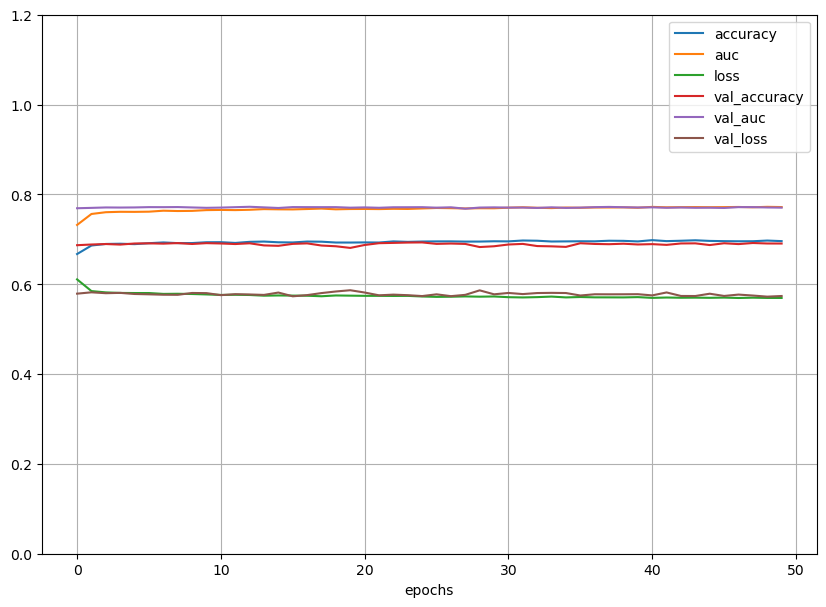

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(figsize=(10, 7))
plt.grid(True)
plt.gca().set_ylim(0, 1.2)
plt.xlabel("epochs")
plt.show()

In [19]:
test_loss, test_acc, test_prec = network_team.evaluate(X_test_team, y_test)

1332/1332 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6635 - auc: 0.7559 - loss: 0.5973


In [20]:
print('test_acc:', test_acc)
print('test_prec:', test_prec)
print('test_loss:', test_loss)

test_acc: 0.6634899973869324
test_prec: 0.7559070587158203
test_loss: 0.5973491072654724


In [21]:
network_team.save("../Data/Model/Neuronal_net.keras")

# Verificación modelo

In [22]:
model = keras.models.load_model("../Data/Model/Neuronal_net.keras")